In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df=pd.read_csv("EV_Battery_Dataset_1.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Cycle          1500 non-null   int64  
 1   Voltage_V      1500 non-null   float64
 2   Current_A      1500 non-null   float64
 3   Temperature_C  1500 non-null   float64
 4   Capacity_Ah    1500 non-null   float64
 5   Time_s         1500 non-null   float64
 6   SOH_pct        1500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 82.2 KB


In [4]:
df.describe()

,Cycle,Voltage_V,Current_A,Temperature_C,Capacity_Ah,Time_s,SOH_pct
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,4.087492,1.497811,28.736160,1.753850,4219.761867,85.553533
std,433.157015,0.065150,0.050800,2.209156,0.135288,355.040433,6.599971
min,1.000000,3.968000,1.350000,24.170000,1.556000,3537.900000,75.920000
25%,375.750000,4.031750,1.463000,26.855000,1.638000,3941.750000,79.880000
50%,750.500000,4.088000,1.499000,28.730000,1.724500,4155.550000,84.100000
75%,1125.250000,4.144000,1.531000,30.625000,1.860250,4468.150000,90.725000
max,1500.000000,4.206000,1.662000,33.410000,2.063000,5416.000000,100.620000


In [5]:
corr=df.corr(numeric_only=True)

print(corr["SOH_pct"].sort_values(ascending=False))

SOH_pct          1.000000
Capacity_Ah      0.999998
Voltage_V        0.976666
Time_s           0.911915
Current_A        0.016518
Temperature_C   -0.953501
Cycle           -0.979264
Name: SOH_pct, dtype: float64


In [6]:
target="SOH_pct"

remove_cols=[target, "Capacity_Ah"]

X = df.drop(remove_cols, axis=1)
y=df[target]

In [8]:
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
model=LinearRegression()

model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.36863447396255156
RMSE: 0.4607101874610993
R2: 0.9950949735800011


In [16]:
model.coef_

array([-7.05944785e-01,  1.10986278e-01,  2.56243550e+00, -6.10836571e-03,
        6.32907330e+00])

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Time_s,6.329073
2,Current_A,2.562435
1,Voltage_V,0.110986
3,Temperature_C,-0.006108
0,Cycle,-0.705945


In [18]:
residuals = y_test - y_pred

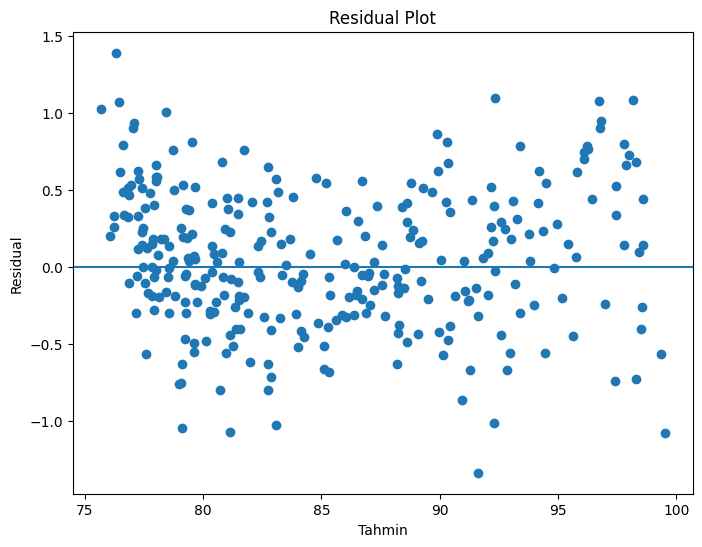

In [19]:
from matplotlib import pyplot as plt


plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Tahmin")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()